# DS 3000 HW 2

#! snip: HW2
# $\color{red}{\text{SOLUTIONS}}$ 
#! snip-end

Due: Wednesday May 27 @ 11:59 PM EST

### Submission Instructions
Upload this `ipynb` file directly to Gradescope.  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the `ipynb` file to Gradescope.

### Tips for success
- Start early
- Make use of Slack
- Remember to use cells, headings and markdown to make the notebook easy to read (if I can't find the answer to a problem, you will receive no points for it)
- Collaborate: bounce ideas off of each other, if you are having trouble you can ask your classmates or Dr. Gerber for help with specific issues, however...
- [(See)](http://www.northeastern.edu/osccr/academic-integrity), i.e. you are welcome to **talk about/discuss** (*not* show or allow each other to copy your answers to) the problems.

### Prize for 3.1

Whoever builds the best model (evaluated in terms of both cross validated test $R^2$ and meeting assumptions) will receive a Belgian waffle.

In [1]:
# functions for you
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Part 1: Writing Your Own Linear Regression Functions

In this part, you will write your own linear regression functions that can (and will) be used for both Part 2 and Part 3. You must make sure that your functions pass the assert statements in each sub-part.

## Part 1.1: Line of Best Fit Function (20 points)

Write the function `line_of_best_fit`, including well written docstring, which takes as arguments `X` (an array, either 1-d or 2-d which includes all the predictor values, not including bias term) and `y` (a 1-d array which includes all corresponding response values to `X`) and returns the vector containing the coefficients for the line of best fit, including an intercept term. I have written the `add_bias_column` function below which you will want to use within your `line_of_best_fit` function. **Make sure the assert statement written in the final code cell of this sub-part passes.**

In [2]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [3]:
#! snip: HW2

def line_of_best_fit(X, y):
    """
    Args:
        X (array): an 1-d or 2-d array with columns representing the features to be passed (does not include intercept)
        y (array): an 1-d array with values to be predicted

    Returns:
        m (array): an array containing all the line of best fit coefficients
    """

    # add bias column
    X = add_bias_column(X)

    # calculate line of best fit
    b = np.linalg.inv(X.T @ X) @ (X.T @ y)

    return b

#! snip-end

In [4]:
X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])

assert (np.isclose(line_of_best_fit(X, y), np.array([3., 1.]))).all()

## Part 1.2: Prediction and Assessment Function (20 points)

Write the function `linreg_predict`, including well written docstring, which takes as arguments:

- `Xnew` (an array, either 1-d or 2-d which includes all the $p$ predictor features, not including bias term)
- `ynew` (a 1-d array which includes all corresponding response values to `Xnew`)
- `b` (a 1-d array of length $p+1$ which contains the coefficients from the `line_of_best_fit` function)

The function should return a dictionary containing four key-value pairs:

- `'ypreds'` (the predicted values from applying `m` to `Xnew`)
- `'resids'` (the residuals, the differences between `ynew` and `ypreds`)
- `'mse'` (the mean squared error)
- `'r2'` (the coefficient of determination ($R^2$) representing the proportion of variability in `ynew` explained by the line of best fit
  - You **do not** have to calculate this manually; you may use the `r2_score` function from `sklearn` (imported for you below)

**Note** you will want to use the `add_bias_column` again within your function before calculating all the outputs in your dictionary. **Also, make sure the assert statement written in the final code cell of this sub-part passes.**

In [5]:
from sklearn.metrics import r2_score

In [6]:
#! snip: HW2

def linreg_predict(Xnew, ynew, b):
    """
    Args:
        Xnew (array): an 1-d or 2-d array with p columns representing the feature values of the new data (does not include intercept)
        ynew (array): an 1-d array with response values of new data
        b (array): an 1-d array of length p+1 which is the output from the line_of_best_fit function ran on training data with same features as Xnew

    Returns:
        Output (dict): a dictionary containing the following key-value pairs:
            'ypreds': the predicted values of Xnew
            'resids': the residuals (ynew - ypreds)
            'mse': the mean squared error
            'r2': the R-squared value
    """

    # adds the bias column
    Xnew = add_bias_column(Xnew)

    # gets the predictions
    ypreds = Xnew @ b

    # gets the residuals
    resids = ypreds - ynew

    # gets the mse
    mse = np.mean(resids ** 2)

    # gets the r2
    r2 = r2_score(ynew, ypreds)

    Output = {'ypreds': ypreds,
              'resids': resids,
              'mse': mse,
              'r2': r2}

    return Output

#! snip-end

In [7]:
def compare_dicts(dict1, dict2):
    """ compares two dictionaries

    Args:
        dict1 (dict): the first dictionary
        dict2 (dict): the second dictionary

    Returns:
        (bool) False if the dictionaries are not close to being the same, True if they are
    """
    
    if dict1.keys() != dict2.keys():
        return False

    for key in dict1:
        if not np.isclose(dict1[key], dict2[key]).all():
            return False

    return True

expected_out = {'ypreds': np.array([3., 5., 4., 3., 7.]),
                'resids': np.array([0., -3., 2., 0., 1.]),
                'mse': 2.8,
                'r2': 0.4444444444444444}

X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])

b = line_of_best_fit(X, y)
out = linreg_predict(X, y, b)

assert compare_dicts(expected_out, out)

# Part 2: Belgium Energy Simple Linear Regression

For this problem you will use the `GDP_Energy_WBdat.csv` file on Canvas. The data set contains the GDP (€ per capita), Total Fossil Fuel Energy Consumption (as a \% of total energy), $\text{CO}^2$ emissions (kt), and Urban Population of the current 27 European Union member states from 1990 to 2015 (with a few years/countries missing). It was accessed via the [World Bank API](https://datahelpdesk.worldbank.org/knowledgebase/topics/125589).

## Part 2.1: Reading, Curating, and Exploring Data (10 points)

Read in the data set and create the `CO2_Upop` column (we did this in class: i.e. create a column which scales $\text{CO}^2$ emissions by Urban Population). Print the head to show it worked.

Subset the data to only include observations from Belgium. Print the head to show it worked.

Then, **YOU DECIDE** which two features (one input, one output) you want to build a simple linear regression model for by doing some data exploration and visualization. In this part 2, you will choose one $x$ feature to predict one $y$ feature. 

**You must** provide a markdown cell with your reasoning which references (a) why you think there may be a useful causal relationship between the two features and (b) some numerical summary statistics and plots (i.e. perhaps correlation and a scatterplot).

**Note:** the input feature cannot be country or date.

In [13]:
#! snip: HW2

worldbank_df = pd.read_csv("C:/Users/eager/OneDrive - Northeastern University/Desktop/NORTHEASTERN/Summer 2026/DoC 2026/CS 4973 SU2026/26su-DoC-Project-Profs/datasets/GDP_Energy_WBdat.csv")
worldbank_df['CO2_Upop'] = worldbank_df.CO2_emit/worldbank_df.Urban_pop
worldbank_df.head()

#! snip-end

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
0,Austria,1990,21680.989623,79.132345,58275.7,4833974.0,0.012055
1,Austria,1991,22410.911767,79.127007,62423.2,4861464.0,0.012840
2,Austria,1992,24880.164118,77.237211,57668.0,4893935.0,0.011784
3,Austria,1993,24081.527793,77.011142,57804.0,4912877.0,0.011766
4,Austria,1994,25646.700659,77.585708,58288.2,4910076.0,0.011871


In [14]:
#! snip: HW2

belgium_bool = worldbank_df.country == "Belgium"
belgium_df = worldbank_df.loc[belgium_bool,:]
belgium_df.head()

#! snip-end

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
26,Belgium,1990,20600.375279,75.815870,109312.6,9606261.0,0.011379
27,Belgium,1991,21041.660652,76.397007,113960.1,9650427.0,0.011809
28,Belgium,1992,23372.619171,75.932201,112329.3,9697796.0,0.011583
29,Belgium,1993,22283.936021,75.935015,110108.3,9743821.0,0.011300
30,Belgium,1994,24208.554793,77.649375,114901.4,9781788.0,0.011746


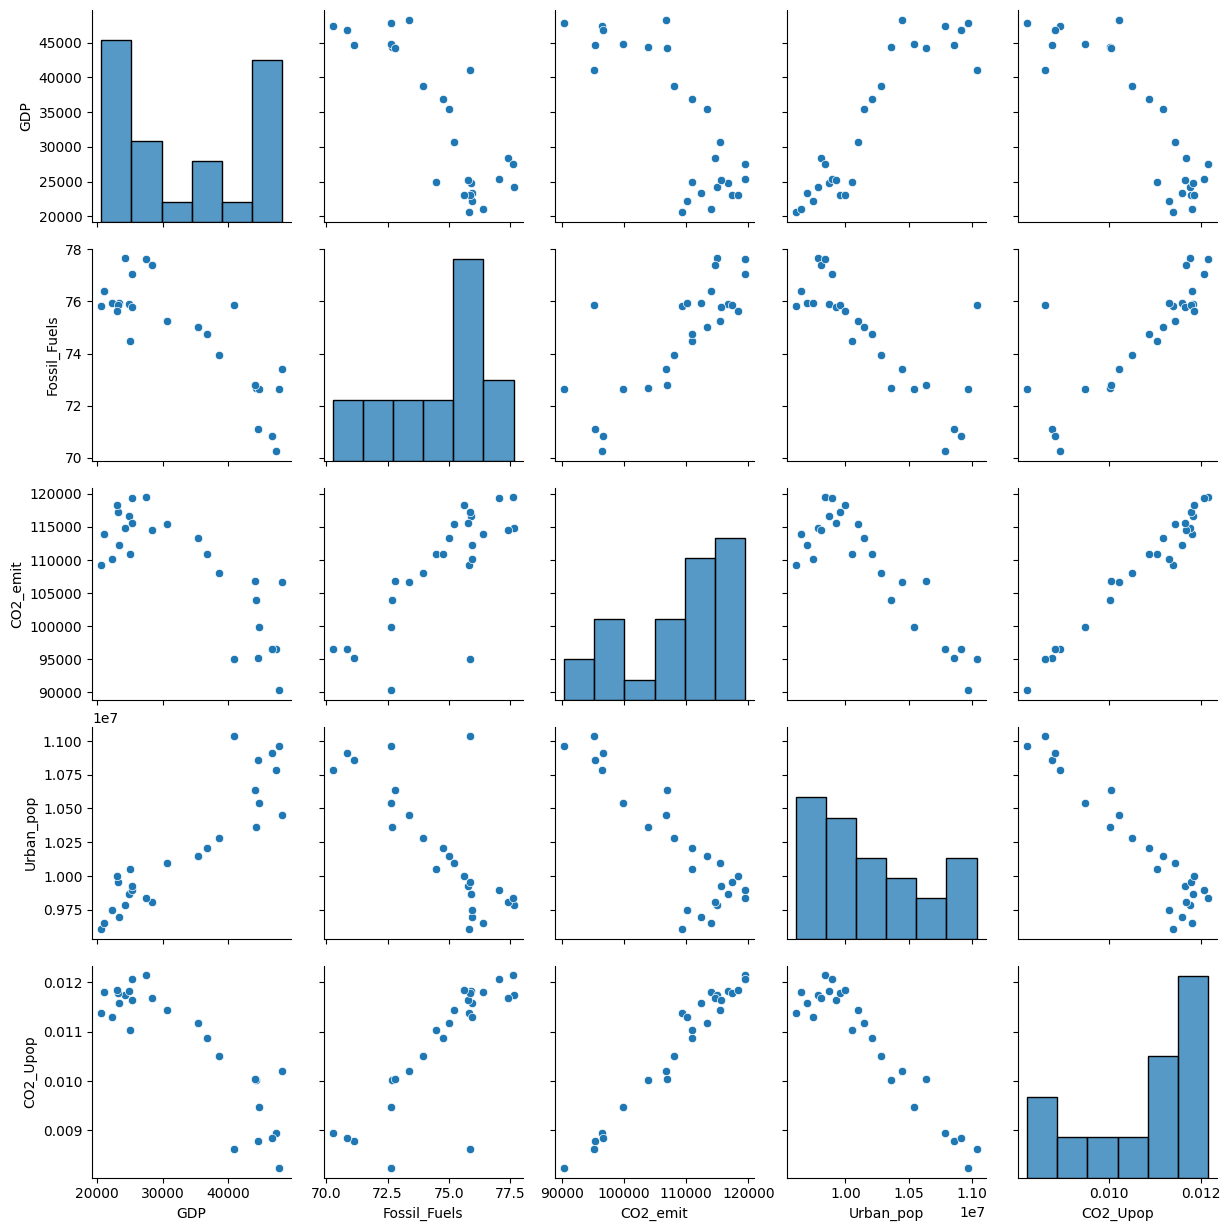

In [15]:
#! snip: HW2

sns.pairplot(belgium_df.iloc[:,2:])

#! snip-end

In [16]:
#! snip: HW2

belgium_df.iloc[:,2:].corr()

#! snip-end

,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
GDP,1.000000,-0.829917,-0.810480,0.910999,-0.880584
Fossil_Fuels,-0.829917,1.000000,0.791284,-0.796344,0.826846
CO2_emit,-0.810480,0.791284,1.000000,-0.874098,0.982416
Urban_pop,0.910999,-0.796344,-0.874098,1.000000,-0.948383
CO2_Upop,-0.880584,0.826846,0.982416,-0.948383,1.000000


#! snip: HW2

Answers will vary. I'm choosing Fossil Fuels and GDP.

#! snip-end

## Part 2.2: Cross Validate, Predict, MSE, and $R^2$ (10 points)

Create arrays `X` and `y` which contain your chosen $x$ and $y$ features (these will both be 1-d arrays for this problem).

Use the `train_test_split` function (with the **the `random_state=42` option**) which I've imported for you below to create a single-fold (70-30 split) cross validation set (i.e. `Xtrain`, `Xtest`, `ytrain`, `ytest`) using the data you cleaned in Part 2.1. In other words, for example, the `Xtrain` set should contain a random subset of about 70\% of the `X` values.

Then **standardize** the input feature (for both training and test; you can use the `StandardScaler` function I've imported for you below) using the **training** mean and standard deviation.
- **Note**: you don't really have to do this hear, since we're doing simple linear regression (one $x$ and one $y$) but you'll want to do this same strategy in the future parts where you have more than one $x$, so may as well practice.

Using your functions from Part 1, apply the `line_of_best_fit` function to training data and use the `linreg_predict` function with the test data (and the output from the first function). 

Print out the resulting cross validated **test** $MSE$ and $R^2$ values and **then**, in a markdown cell, interpret $R^2$ and discuss (based on that alone) if you think it is reasonable to predict your $y$ value with your $x$ value.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [18]:
#! snip: HW2

X = np.array(belgium_df.Fossil_Fuels)
y = np.array(belgium_df.GDP)

crossval = train_test_split(X, 
                            y,
                            test_size=0.3,
                            random_state=42)

Xtrain, Xtest, ytrain, ytest = crossval

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain.reshape(-1,1)).flatten()
Xtest = scaler.transform(Xtest.reshape(-1,1)).flatten()

train_line = line_of_best_fit(Xtrain, ytrain)
test_line = linreg_predict(Xtest, ytest, train_line)
print(f'Test MSE: {test_line["mse"]}')
print(f'Test R²: {test_line["r2"]}')

#! snip-end

Test MSE: 35122421.53703083
Test R²: 0.5651541384659948


#! snip: HW2

$R^2$ will vary depending on the two features chosen, but generally (for most of them), it seems like (at least just based on this value) it may be pretty reasonable to predict $y$ with $x$, since most $R^2$ I see from the pairwise regressions are greater than 50\%.

#! snip-end

## Part 2.3: Plot and Interpret the Full Line (10 points)

Now, fit the regression model to the full data set (you can use the unstandardized values), then use the `show_fit()` function below to plot it and recover the final best fit line for the model. **Note** that your `line_of_best_fit` function is the only one you need here, and that you will have to remember which value in the output vector is the slope and which is the intercept.

**In a markdown cell**, interpret both the slope and intercept in the context of the problem, explaining what they mean. **IF** you standardized both the features earlier, it will impact your interpretation.

In [19]:
sns.set()

def get_mse(y_true, y_pred):
    """ gets the MSE

    Args:
        y_true (array): the true y values
        y_pred (array): the predicted y values

    Returns:
        the mean squared error

    """
    
    return np.mean((y_true - y_pred) ** 2)

def show_fit(X, y, slope, intercept):
    """ plots a simple linear regression line through x y points and prints the slope, intercept, and MSE

    Args:
        X (array): the design matrix
        y (array): the response variable
        slope (float): the slope
        intercept (float): the intercept

    Returns:
        A plot (I'm getting lazy with these...)
    """
    
    plt.figure()
    
    # in case this wasn't done before, transform the input data into numpy arrays and flatten them
    x = np.array(X).ravel()
    y = np.array(y).ravel()
    
    # plot the actual data
    plt.scatter(x, y, label='data')
    
    # compute linear predictions 
    # x is a numpy array so each element gets multiplied by slope and intercept is added
    y_pred = slope * x + intercept
    
    # plot the linear fit
    plt.plot(x, y_pred, color='black',
             ls=':',
             label='linear fit')
    
    plt.legend()
    
    plt.xlabel('x')
    plt.ylabel('y')
    
    # print the mean squared error
    y_pred = slope * x + intercept
    mse = get_mse(y_true=y, y_pred=y_pred)
    plt.suptitle(f'y_hat = {slope:.3f} * x + {intercept:.3f}, MSE = {mse:.3f}')

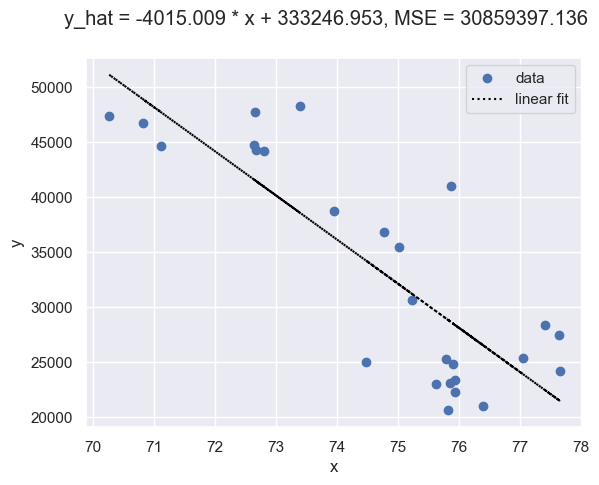

In [20]:
#! snip: HW2

best_line = line_of_best_fit(X, y)
show_fit(X, y, best_line[1], best_line[0])

#! snip-end

#! snip: HW2

The slope of -4015 means that for every additional % Belgium's total energy consumption comes from Fossil Fuel, it's GDP decreases by 4015 euros per capita. The intercept of 333247 means that when Belgium has 0% Fossil Fuel consumption, its GDP per capita is 333247 euros per capita.

#! snip-end

## Part 2.4: Check Assumptions and Make Recommendations (10 points)

Use two plots to check to see if the residuals meet the assumptions for performing a *simple* linear regression:
1. linearity and homoscedasticity
2. no autocorrelation

**Note** that you will want to use your `linreg_predict` function, using the **full data set** as your `Xnew` and `ynew` values, to get the residuals for the purposes of this question.

Then, **in a markdown cell**, write 3-4 sentences about whether the model meets the assumptions, what that tells you about the usefulness of the model, and recommendations for next steps (if any).

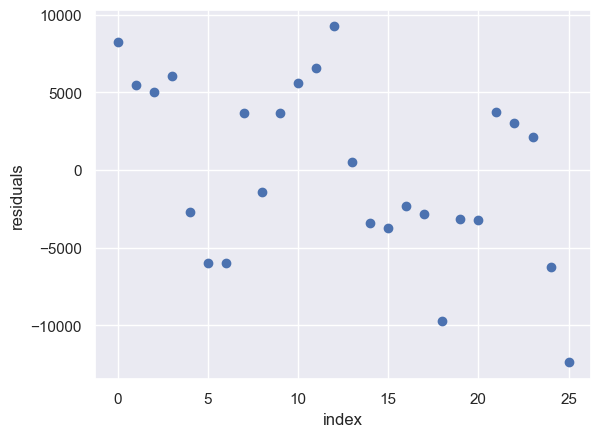

In [21]:
#! snip: HW2

pred_dict = linreg_predict(X, y, best_line)
residuals = pred_dict['resids']

# check no autocorrelation
plt.scatter(x = range(len(residuals)), y = residuals)
plt.xlabel('index')
plt.ylabel('residuals');

#! snip-end

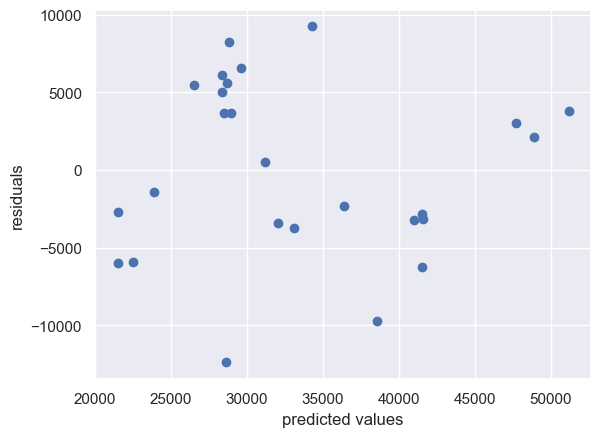

In [22]:
#! snip: HW2

# check constant variance/linearity
plt.scatter(x = pred_dict['ypreds'], y = residuals)
plt.xlabel('predicted values')
plt.ylabel('residuals');

#! snip-end

#! snip: HW2

Answers will vary depending on the $x$ and $y$ values. Independence here seems to be reasonable, as there are no major patterns in the first plot. Not sure about linearity; seems like there might be a curve suggesting a non-linear trend? Constant variance is also not great looking; there's a larger spread to the left than to the right (at least it seems that way to me).

#! snip-end

# Part 3: More Complex Regression 

## Part 3.1: Predicting GDP (15 points)

Suppose a Belgian policy maker comes to you now and asks you to use this data to build a model to predict `GDP` **specifically**. To build a linear regression model for GDP using **more than 1 predictor** (i.e. include at least one additional $x$ feature(s) as linear terms for your model or create your own, new $x$ features using some feature engineering--feel free to get fancy if you like):

1. Justify your choices of predictors in a few sentences; why are you including these predictors/why do you think they will be helpful for predicting GDP?
2. Fit your model to a training set and the evaluate on a testing set (standardized using the training set); report the test $MSE$, $R^2$. Then, fit the full data set and interpret the intercept and slopes (you will have multiple slopes, since you will have more than 1 predictor).
3. Check the assumptions of linearity, homoscedasticity, and no autocorrelation using the residuals of the full data set.
4. Finally, decide (based on what you've done) if the model you built seems like a useful model that you would be willing to show to the Belgian policy maker.

#### Waffle Prize

Remember, whoever builds the best model (evaluated in terms of both cross validated test $R^2$ and meeting assumptions) will receive a Belgian waffle.

In [23]:
#! snip: HW2

# let's use Fossil_Fuels and CO2_Upop to predict GDP
X = np.array(belgium_df[['Fossil_Fuels', 'CO2_Upop']])
# standardize

crossval = train_test_split(X, 
                            y,
                            test_size=0.3,
                            random_state=42)

Xtrain, Xtest, ytrain, ytest = crossval

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

train_line = line_of_best_fit(Xtrain, ytrain)
test_line = linreg_predict(Xtest, ytest, train_line)
print(f'Test MSE: {test_line["mse"]}')
print(f'Test R²: {test_line["r2"]}')

best_line = line_of_best_fit(X, y)
print(best_line)

#! snip-end

Test MSE: 16875105.60552001
Test R²: 0.7910716427176618
[ 2.04241540e+05 -1.55706424e+03 -5.09216268e+06]


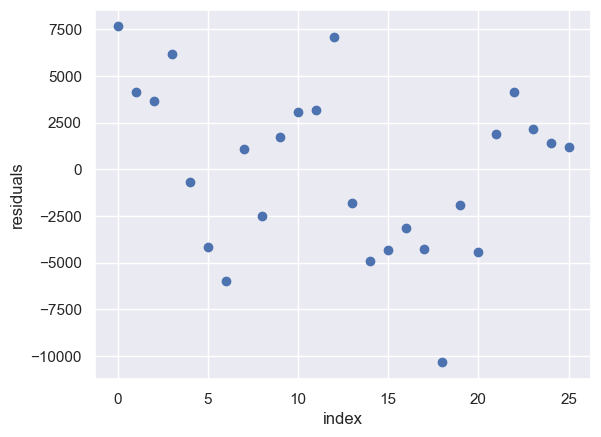

In [24]:
#! snip: HW2

pred_dict = linreg_predict(X, y, best_line)
residuals = pred_dict['resids']

# check no autocorrelation
plt.scatter(x = range(len(residuals)), y = residuals)
plt.xlabel('index')
plt.ylabel('residuals');

#! snip-end

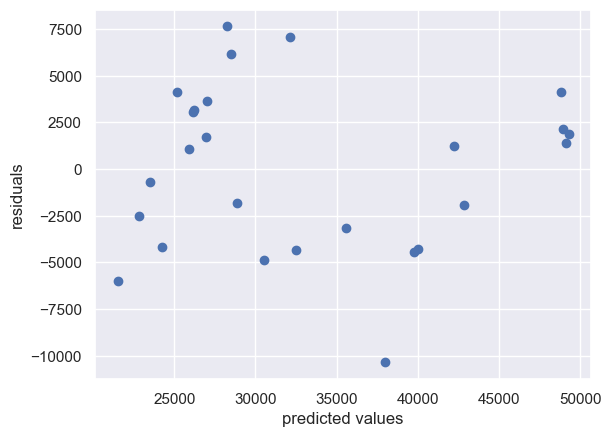

In [25]:
#! snip: HW2

# check constant variance/linearity
plt.scatter(x = pred_dict['ypreds'], y = residuals)
plt.xlabel('predicted values')
plt.ylabel('residuals');

#! snip-end

#! snip: HW2

Answers will vary here. The negative slopes here suggest that both `Fossil_Fuels` and `CO2_Upop` negatively impact `GDP`; the former less so than the latter (remember these are standardized $x$ inputs). However, while the $R^2$ is pretty high, I still think the model could be better; there may still be some constant variance issues, and it definitely seems like `CO2_Upop` should be included as a polynomial term, since linearity is clearly violated.

#! snip-end

## Part 3.2: The Last Assumption (5 points)

The Belgian policy maker, when assigning you the previous task, had suggested to use all the other features to help predict `GDP`. Whether you did or not, do you think there may be reason to believe such a model would be at risk of multicollinearity issues? Explain (to the policy maker) why that may or may not be in a few sentences.

#! snip: HW2

Yes! All the features are strongly correlated; it's entirely possible that even though it seems that both (for example) Fossil Fuels and CO2 emissions have a large impact on GDP, it could be that some other feature may be impacting both (for example, countries that have large industrial capacity may both use a lot of fossil fuels and emit a lot of CO2, and that that feature (industrial capacity) is a far more important feature for predicting GDP).

#! snip-end

## Part 3.3: Extra Credit (5 points)

We want to compare a simple linear model (if you haven't already) predicting GDP with Fossil Fuels, and a **quadratic** model with Fossil Fuels (i.e. your $X$ design matrix will include a column with Fossil Fuels ($x$ values) and Fossil Fuels squared ($x^2$)). 

1. Fit both models with the full data set and compare their $MSE$ and $R^2$ values; which model (based on these values) would you choose?
    - **Note** Ideally you would do this with cross validation and test sets, but I want to save you some time if you attempt this!
2. Check the assumptions of homoscedasticity and no autocorrelation using residual plots for both models.
3. Make a declaration about which model is "better", and if you think the "better" model is actually good, or may need more work.